In [1]:
# ============================================================
# FSDL 2022 - Lab 8 (Modernized)
# Monitoring Machine Learning Systems
# ============================================================

# Install only lightweight, actively maintained packages

!pip -q install torch torchvision pandas matplotlib tqdm

Using device: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 21.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 340kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.4MB/s]


Monitoring dataset size: 500 images


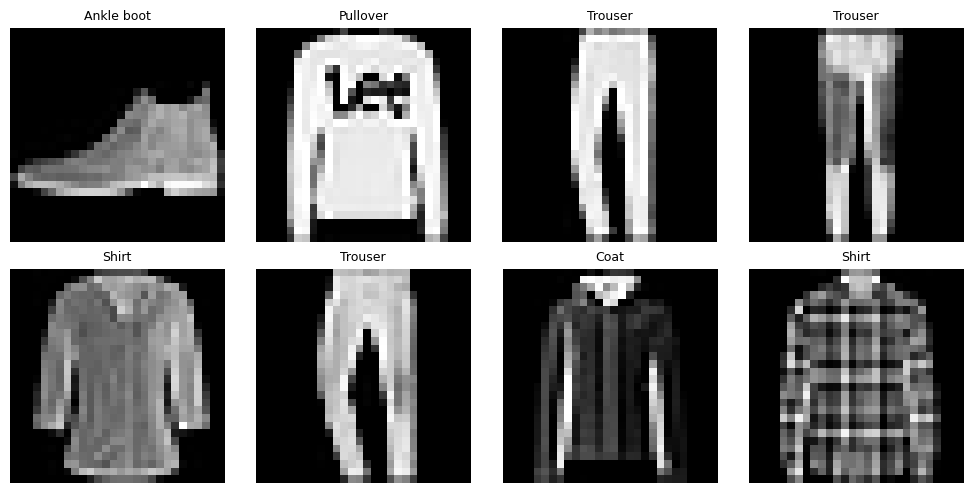

In [2]:
# ============================================================
# Imports
# ============================================================

import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

transform = transforms.ToTensor()

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# Small subset for monitoring experiments
test_subset = torch.utils.data.Subset(
    test_dataset,
    range(500)
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

classes = test_dataset.classes

print(f"Monitoring dataset size: {len(test_subset)} images")

# ------------------------------------------------------------
# Preview Dataset
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(10,5))

for ax, (image, label) in zip(axes.flat, test_subset):

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(classes[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# Small CNN (Same Architecture as Lab 7)
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = SimpleCNN().to(device)

print(model)

# ------------------------------------------------------------
# OPTIONAL:
# Load weights from Lab 7 if available
# ------------------------------------------------------------

WEIGHTS_PATH = "simple_cnn_weights.pth"

try:

    model.load_state_dict(
        torch.load(
            WEIGHTS_PATH,
            map_location=device
        )
    )

    print("\n✓ Loaded trained weights.")

except FileNotFoundError:

    print("\nNo trained weights found.")
    print("We'll still use the model to demonstrate monitoring concepts.")

model.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

No trained weights found.
We'll still use the model to demonstrate monitoring concepts.


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Ground Truth
------------
Ankle boot

Prediction Result
-----------------
prediction  : 8
class_name  : Bag
confidence  : 0.1064688116312027
latency_ms  : 105.20558399997526


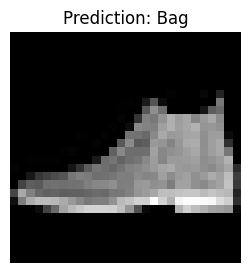

In [4]:
# ============================================================
# Production Prediction Function
# ============================================================

def predict(model, image):

    model.eval()

    if image.ndim == 3:
        image = image.unsqueeze(0)

    image = image.to(device)

    start = time.perf_counter()

    with torch.no_grad():

        logits = model(image)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    latency_ms = (
        time.perf_counter() - start
    ) * 1000

    return {
        "prediction": prediction.item(),
        "class_name": classes[prediction.item()],
        "confidence": confidence.item(),
        "latency_ms": latency_ms
    }


# ------------------------------------------------------------
# Test Prediction
# ------------------------------------------------------------

sample_image, sample_label = test_subset[0]

result = predict(model, sample_image)

print("Ground Truth")
print("------------")
print(classes[sample_label])

print("\nPrediction Result")
print("-----------------")

for key, value in result.items():

    print(f"{key:12}: {value}")

# ------------------------------------------------------------
# Display Image
# ------------------------------------------------------------

plt.figure(figsize=(3,3))

plt.imshow(sample_image.squeeze(), cmap="gray")

plt.title(
    f"Prediction: {result['class_name']}"
)

plt.axis("off")

plt.show()

In [5]:
# ============================================================
# Log Predictions
# ============================================================

prediction_logs = []

NUM_REQUESTS = 100

for i in range(NUM_REQUESTS):

    image, true_label = test_subset[i]

    result = predict(model, image)

    prediction_logs.append({

        "request_id": i + 1,

        "timestamp": pd.Timestamp.now(),

        "true_label": classes[true_label],

        "predicted_label": result["class_name"],

        "confidence": result["confidence"],

        "latency_ms": result["latency_ms"],

        "correct": (
            classes[true_label] ==
            result["class_name"]
        )
    })

print(f"Logged {len(prediction_logs)} inference requests.")

# Preview first few logs
prediction_logs[:3]

Logged 100 inference requests.


[{'request_id': 1,
  'timestamp': Timestamp('2026-07-27 19:18:09.138729'),
  'true_label': 'Ankle boot',
  'predicted_label': 'Bag',
  'confidence': 0.1064688116312027,
  'latency_ms': 1.3048470000285306,
  'correct': False},
 {'request_id': 2,
  'timestamp': Timestamp('2026-07-27 19:18:09.141811'),
  'true_label': 'Pullover',
  'predicted_label': 'T-shirt/top',
  'confidence': 0.10627234727144241,
  'latency_ms': 1.1227649999909772,
  'correct': False},
 {'request_id': 3,
  'timestamp': Timestamp('2026-07-27 19:18:09.143442'),
  'true_label': 'Trouser',
  'predicted_label': 'Bag',
  'confidence': 0.10613566637039185,
  'latency_ms': 0.9540710000237596,
  'correct': False}]

In [6]:
# ============================================================
# Monitoring DataFrame
# ============================================================

logs_df = pd.DataFrame(prediction_logs)

display(logs_df.head())

print("\n==============================")
print("Monitoring Summary")
print("==============================")

print(f"Total Requests : {len(logs_df)}")

print(f"Accuracy       : {logs_df['correct'].mean():.2%}")

print(f"Average Confidence : {logs_df['confidence'].mean():.3f}")

print(f"Average Latency    : {logs_df['latency_ms'].mean():.3f} ms")

print(f"Maximum Latency    : {logs_df['latency_ms'].max():.3f} ms")

print(f"Minimum Latency    : {logs_df['latency_ms'].min():.3f} ms")

print(f"Median Latency     : {logs_df['latency_ms'].median():.3f} ms")

# ------------------------------------------------------------
# Correct vs Incorrect Predictions
# ------------------------------------------------------------

print("\nPrediction Counts")

print(logs_df["correct"].value_counts())

,request_id,timestamp,true_label,predicted_label,confidence,latency_ms,correct
0,1,2026-07-27 19:18:09.138729,Ankle boot,Bag,0.106469,1.304847,False
1,2,2026-07-27 19:18:09.141811,Pullover,T-shirt/top,0.106272,1.122765,False
2,3,2026-07-27 19:18:09.143442,Trouser,Bag,0.106136,0.954071,False
3,4,2026-07-27 19:18:09.145045,Trouser,Bag,0.106410,1.059120,False
4,5,2026-07-27 19:18:09.146051,Shirt,Bag,0.106267,0.549804,False



Monitoring Summary
Total Requests : 100
Accuracy       : 7.00%
Average Confidence : 0.106
Average Latency    : 1.285 ms
Maximum Latency    : 6.803 ms
Minimum Latency    : 0.484 ms
Median Latency     : 0.948 ms

Prediction Counts
correct
False    93
True      7
Name: count, dtype: int64


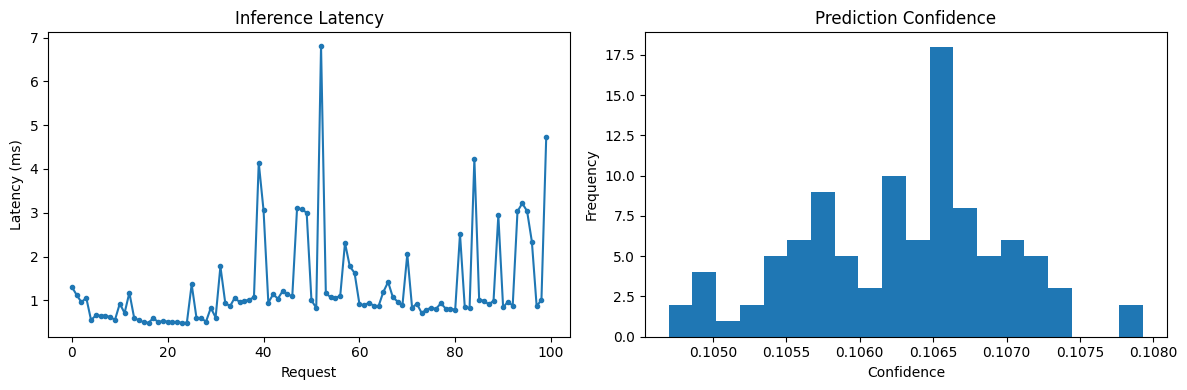

In [7]:
# ============================================================
# Monitoring Dashboard: Latency & Confidence
# ============================================================

plt.figure(figsize=(12, 4))

# ------------------------------------------------------------
# Latency Plot
# ------------------------------------------------------------

plt.subplot(1, 2, 1)

plt.plot(
    logs_df["latency_ms"],
    marker="o",
    markersize=3
)

plt.title("Inference Latency")
plt.xlabel("Request")
plt.ylabel("Latency (ms)")

# ------------------------------------------------------------
# Confidence Histogram
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

plt.hist(
    logs_df["confidence"],
    bins=20
)

plt.title("Prediction Confidence")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Confidence Monitoring
# ============================================================

CONFIDENCE_THRESHOLD = 0.60

low_confidence = logs_df[
    logs_df["confidence"] < CONFIDENCE_THRESHOLD
]

print("=" * 60)
print("Low-Confidence Monitoring")
print("=" * 60)

print(f"Threshold              : {CONFIDENCE_THRESHOLD:.2f}")
print(f"Flagged Predictions    : {len(low_confidence)}")
print(
    f"Percentage Flagged     : "
    f"{len(low_confidence) / len(logs_df):.2%}"
)

if len(low_confidence) > 0:

    print("\nExamples\n")

    display(
        low_confidence[
            [
                "request_id",
                "predicted_label",
                "confidence",
                "latency_ms",
                "correct"
            ]
        ].head(10)
    )

else:

    print("\nNo low-confidence predictions found.")

# ------------------------------------------------------------
# Alert
# ------------------------------------------------------------

flag_ratio = len(low_confidence) / len(logs_df)

if flag_ratio > 0.20:

    print("\n⚠ ALERT: More than 20% of predictions are low confidence.")

else:

    print("\n✓ Confidence levels look healthy.")

Low-Confidence Monitoring
Threshold              : 0.60
Flagged Predictions    : 100
Percentage Flagged     : 100.00%

Examples



,request_id,predicted_label,confidence,latency_ms,correct
0,1,Bag,0.106469,1.304847,False
1,2,T-shirt/top,0.106272,1.122765,False
2,3,Bag,0.106136,0.954071,False
3,4,Bag,0.106410,1.059120,False
4,5,Bag,0.106267,0.549804,False
5,6,Bag,0.107028,0.653346,False
6,7,Bag,0.107847,0.650239,False
7,8,Bag,0.106493,0.651306,False
8,9,Bag,0.106383,0.616814,False
9,10,Bag,0.106216,0.555327,False



⚠ ALERT: More than 20% of predictions are low confidence.


Created 100 simulated production images.


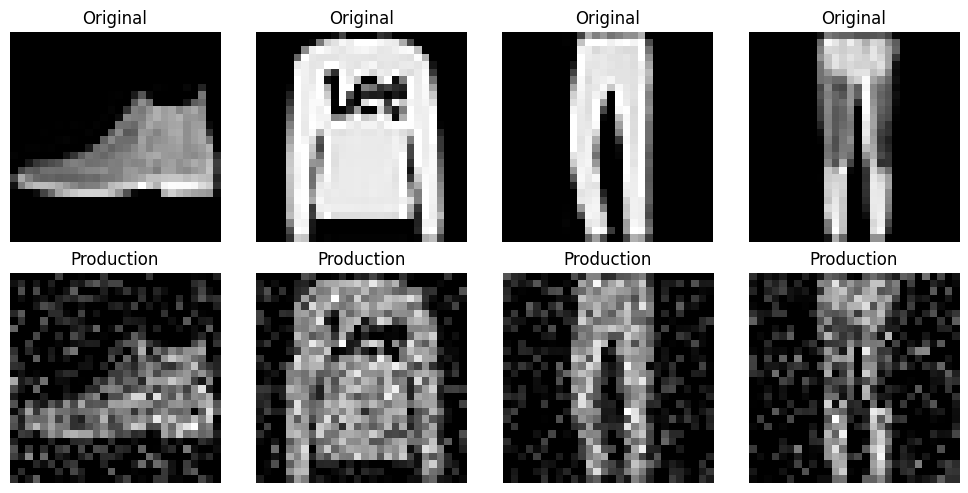

In [9]:
# ============================================================
# Simulate Data Drift
# ============================================================

drifted_images = []

NUM_SAMPLES = 100

for i in range(NUM_SAMPLES):

    image, _ = test_subset[i]

    # Simulate a change in production data
    # (darker images + random noise)

    drifted = image * 0.60
    drifted += torch.randn_like(image) * 0.15

    drifted = torch.clamp(
        drifted,
        0.0,
        1.0
    )

    drifted_images.append(drifted)

print(f"Created {len(drifted_images)} simulated production images.")

# ------------------------------------------------------------
# Compare Original vs Drifted Images
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(10,5))

for col in range(4):

    original, _ = test_subset[col]

    axes[0, col].imshow(
        original.squeeze(),
        cmap="gray"
    )
    axes[0, col].set_title("Original")
    axes[0, col].axis("off")

    axes[1, col].imshow(
        drifted_images[col].squeeze(),
        cmap="gray"
    )
    axes[1, col].set_title("Production")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

Data Drift Report
Original Mean Pixel Value : 0.2928
Production Mean Pixel Value: 0.2100
Difference                : 0.0829


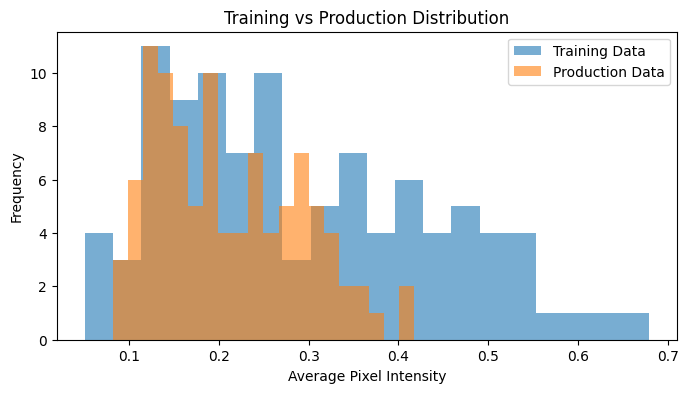


⚠ DATA DRIFT DETECTED


In [10]:
# ============================================================
# Detect Data Drift
# ============================================================

# Calculate average pixel intensity
original_means = []
drifted_means = []

for i in range(NUM_SAMPLES):

    original, _ = test_subset[i]

    original_means.append(
        original.mean().item()
    )

    drifted_means.append(
        drifted_images[i].mean().item()
    )

original_mean = np.mean(original_means)
drifted_mean = np.mean(drifted_means)

print("=" * 60)
print("Data Drift Report")
print("=" * 60)

print(f"Original Mean Pixel Value : {original_mean:.4f}")
print(f"Production Mean Pixel Value: {drifted_mean:.4f}")

difference = abs(
    original_mean - drifted_mean
)

print(f"Difference                : {difference:.4f}")

# ------------------------------------------------------------
# Visual Comparison
# ------------------------------------------------------------

plt.figure(figsize=(8,4))

plt.hist(
    original_means,
    bins=20,
    alpha=0.6,
    label="Training Data"
)

plt.hist(
    drifted_means,
    bins=20,
    alpha=0.6,
    label="Production Data"
)

plt.xlabel("Average Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Training vs Production Distribution")

plt.legend()

plt.show()

# ------------------------------------------------------------
# Simple Alert
# ------------------------------------------------------------

DRIFT_THRESHOLD = 0.05

if difference > DRIFT_THRESHOLD:

    print("\n⚠ DATA DRIFT DETECTED")

else:

    print("\n✓ No significant drift detected.")

In [11]:
# ============================================================
# Simulate User Feedback Collection
# ============================================================

feedback_logs = []

NUM_FEEDBACK = 50

for i in range(NUM_FEEDBACK):

    image, true_label = test_subset[i]

    result = predict(model, image)

    # Simulate user feedback
    # If prediction is correct, user is satisfied.
    # Otherwise, user reports an incorrect prediction.

    feedback = {

        "request_id": i + 1,

        "true_label": classes[true_label],

        "predicted_label": result["class_name"],

        "confidence": result["confidence"],

        "feedback": (
            "Correct"
            if result["class_name"] == classes[true_label]
            else "Incorrect"
        )
    }

    feedback_logs.append(feedback)

feedback_df = pd.DataFrame(feedback_logs)

display(feedback_df.head())

print("\nFeedback Summary")
print("--------------------------")

print(feedback_df["feedback"].value_counts())

,request_id,true_label,predicted_label,confidence,feedback
0,1,Ankle boot,Bag,0.106469,Incorrect
1,2,Pullover,T-shirt/top,0.106272,Incorrect
2,3,Trouser,Bag,0.106136,Incorrect
3,4,Trouser,Bag,0.106410,Incorrect
4,5,Shirt,Bag,0.106267,Incorrect



Feedback Summary
--------------------------
feedback
Incorrect    46
Correct       4
Name: count, dtype: int64


In [12]:
# ============================================================
# Error Logging
# ============================================================

error_df = feedback_df[
    feedback_df["feedback"] == "Incorrect"
].copy()

print("=" * 60)
print("Prediction Errors")
print("=" * 60)

print(f"Total Errors: {len(error_df)}")

display(error_df.head(10))

# ------------------------------------------------------------
# Error Statistics
# ------------------------------------------------------------

print("\nMost Frequently Misclassified Labels")

print(
    error_df["true_label"]
    .value_counts()
)

# ------------------------------------------------------------
# Human-in-the-loop Summary
# ------------------------------------------------------------

print("\nRecommendations")

if len(error_df) == 0:

    print("✓ No incorrect predictions found.")
    print("No immediate retraining required.")

else:

    print("• Store these samples for future retraining.")
    print("• Ask human annotators to verify labels.")
    print("• Add corrected samples to the training dataset.")
    print("• Retrain and redeploy the model.")

Prediction Errors
Total Errors: 46


,request_id,true_label,predicted_label,confidence,feedback
0,1,Ankle boot,Bag,0.106469,Incorrect
1,2,Pullover,T-shirt/top,0.106272,Incorrect
2,3,Trouser,Bag,0.106136,Incorrect
3,4,Trouser,Bag,0.106410,Incorrect
4,5,Shirt,Bag,0.106267,Incorrect
5,6,Trouser,Bag,0.107028,Incorrect
6,7,Coat,Bag,0.107847,Incorrect
7,8,Shirt,Bag,0.106493,Incorrect
8,9,Sandal,Bag,0.106383,Incorrect
9,10,Sneaker,Bag,0.106216,Incorrect



Most Frequently Misclassified Labels
true_label
Trouser        7
Sneaker        7
Pullover       6
Coat           5
Shirt          5
Dress          5
Ankle boot     4
Sandal         4
T-shirt/top    3
Name: count, dtype: int64

Recommendations
• Store these samples for future retraining.
• Ask human annotators to verify labels.
• Add corrected samples to the training dataset.
• Retrain and redeploy the model.


MODEL MONITORING DASHBOARD
Total Requests                : 100
Accuracy                      : 7.00%
Average Confidence            : 0.106
Average Latency (ms)          : 1.285
Low Confidence Predictions    : 100
Prediction Errors             : 46


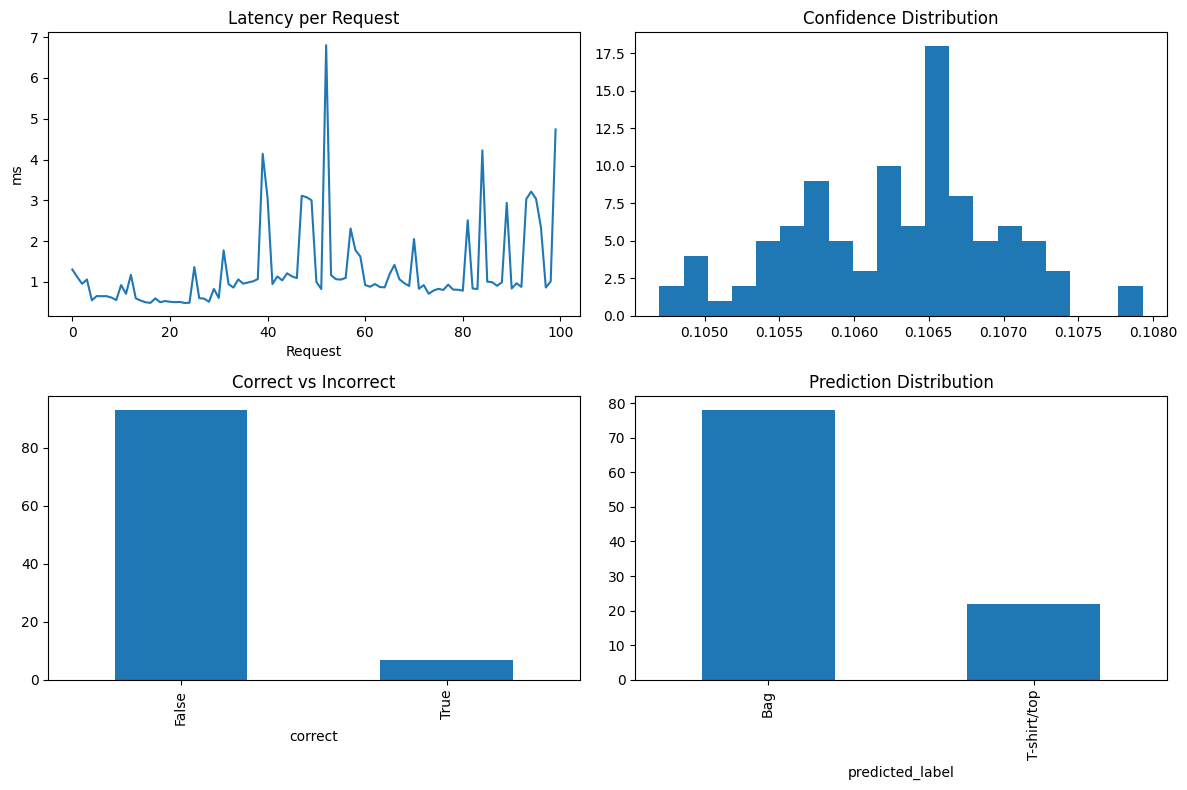

In [13]:
# ============================================================
# Monitoring Dashboard
# ============================================================

dashboard = {
    "Total Requests": len(logs_df),
    "Accuracy": logs_df["correct"].mean(),
    "Average Confidence": logs_df["confidence"].mean(),
    "Average Latency (ms)": logs_df["latency_ms"].mean(),
    "Low Confidence Predictions": len(low_confidence),
    "Prediction Errors": len(error_df)
}

print("=" * 60)
print("MODEL MONITORING DASHBOARD")
print("=" * 60)

for metric, value in dashboard.items():

    if isinstance(value, float):

        if "Accuracy" in metric:
            print(f"{metric:<30}: {value:.2%}")

        elif "Confidence" in metric:
            print(f"{metric:<30}: {value:.3f}")

        else:
            print(f"{metric:<30}: {value:.3f}")

    else:

        print(f"{metric:<30}: {value}")

# ------------------------------------------------------------
# Visual Dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Latency
axes[0,0].plot(logs_df["latency_ms"])
axes[0,0].set_title("Latency per Request")
axes[0,0].set_xlabel("Request")
axes[0,0].set_ylabel("ms")

# Confidence
axes[0,1].hist(logs_df["confidence"], bins=20)
axes[0,1].set_title("Confidence Distribution")

# Prediction correctness
logs_df["correct"].value_counts().plot(
    kind="bar",
    ax=axes[1,0]
)
axes[1,0].set_title("Correct vs Incorrect")

# Predicted classes
logs_df["predicted_label"].value_counts().plot(
    kind="bar",
    ax=axes[1,1]
)
axes[1,1].set_title("Prediction Distribution")

plt.tight_layout()
plt.show()